<a href="https://colab.research.google.com/github/IqmalIskandar/Quality-Aware-Glaucoma-Detection/blob/main/notebooks/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

# Deep Learning Framework
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# For checking if GPU is active
print(f"Is GPU available? {torch.cuda.is_available()}")

Is GPU available? True


In [ ]:
# Change this to your actual file path
path_to_csv = '/content/drive/MyDrive/HYGD_Data/Labels.csv'

df = pd.read_csv(path_to_csv)

# Quick look at the first 5 rows
print(df.head())

# Check the distribution (Glaucoma vs Normal)
print(df['Label'].value_counts())

  Image Name  Patient Label  Quality Score  Unnamed: 4
0    0_0.jpg        0  GON+           6.18         NaN
1    1_0.jpg        1  GON+           5.31         NaN
2    1_1.jpg        1  GON+           4.37         NaN
3    2_0.jpg        2  GON+           3.51         NaN
4    2_1.jpg        2  GON+           4.24         NaN
Label
GON+    548
GON-    199
Name: count, dtype: int64


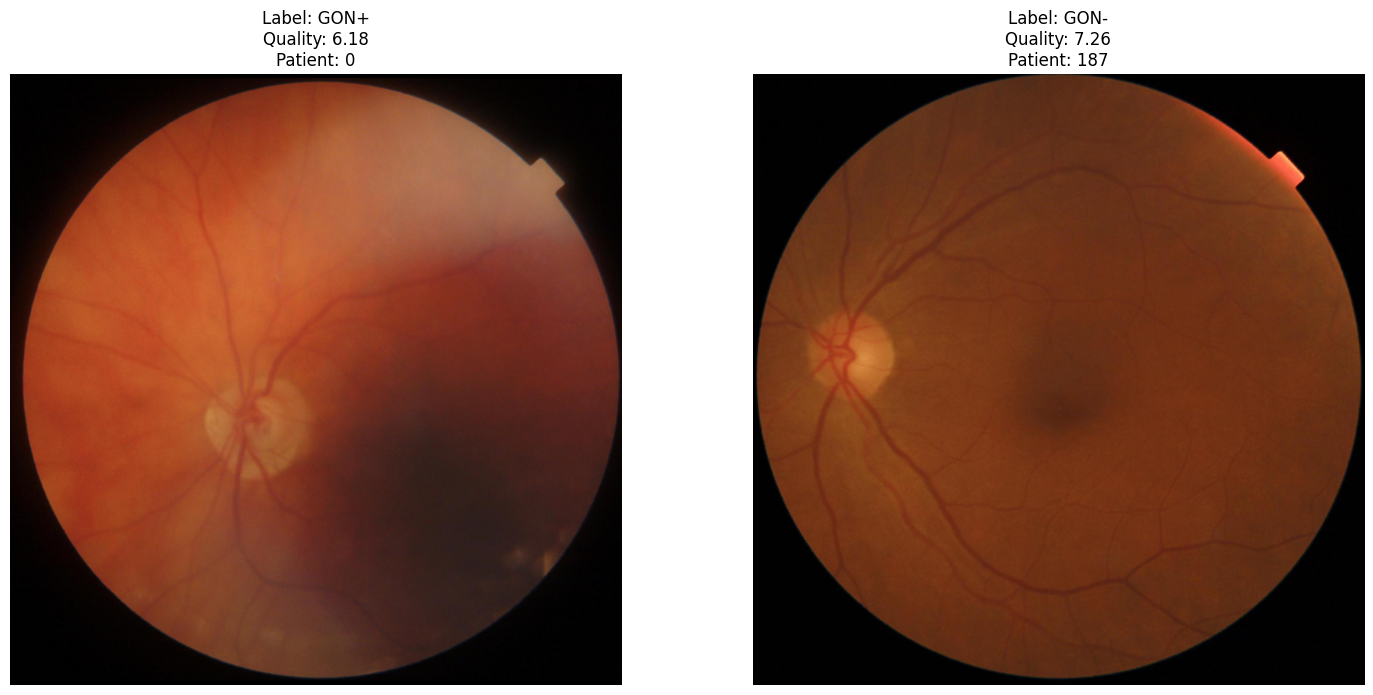

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# 1. Double-check this path!
# Go to the folder in the Colab sidebar, right-click the folder with images, and select "Copy path"
IMG_DIR = '/content/drive/MyDrive/HYGD_Data/Images/'

def show_samples(df, image_folder):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Get one GON+ and one GON- sample
    samples = [
        df[df['Label'] == 'GON+'].iloc[0],
        df[df['Label'] == 'GON-'].iloc[0]
    ]

    for i, sample in enumerate(samples):
        img_name = sample['Image Name']
        img_path = os.path.join(image_folder, img_name)

        # Check if file exists before reading
        if not os.path.exists(img_path):
            print(f"❌ Error: Could not find {img_name} at {img_path}")
            continue

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[i].imshow(img)
        axes[i].set_title(f"Label: {sample['Label']}\nQuality: {sample['Quality Score']}\nPatient: {sample['Patient']}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run it again with the explicit path
show_samples(df, IMG_DIR)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Initialize the splitter
# test_size=0.2 means 20% of patients will be saved for testing
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Create the indices for the split based on the 'Patient' column
train_idx, val_idx = next(gss.split(df, groups=df['Patient']))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print(f"Total Patients: {df['Patient'].nunique()}")
print(f"Training set: {len(train_df)} images ({train_df['Patient'].nunique()} patients)")
print(f"Validation set: {len(val_df)} images ({val_df['Patient'].nunique()} patients)")

# Check if there is any patient overlap (should be 0)
overlap = set(train_df['Patient']).intersection(set(val_df['Patient']))
print(f"Patient overlap: {len(overlap)}")

Total Patients: 288
Training set: 615 images (230 patients)
Validation set: 132 images (58 patients)
Patient overlap: 0


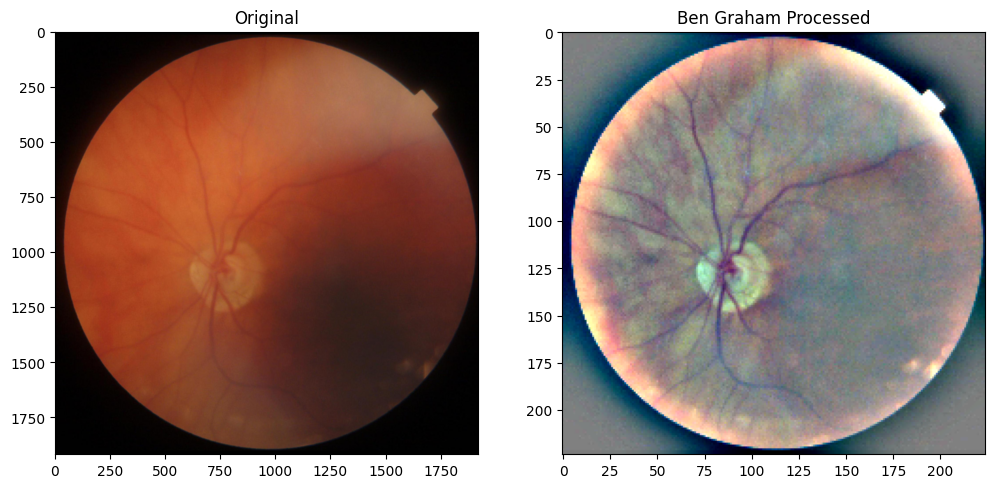

In [ ]:
import cv2
import numpy as np

def ben_graham_processing(img, sigmaX=10):
    # 1. Resize to a standard square (e.g., 224x224)
    img = cv2.resize(img, (224, 224))

    # 2. Gaussian Blur subtraction to normalize lighting
    # This enhances local features like blood vessels
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), sigmaX), -4, 128)

    # 3. Optional: Circular crop (removing the black edges)
    # We'll skip the complex crop for now as the resize handles most of it
    return img

# Let's test it on a sample
test_img_path = os.path.join(IMG_DIR, train_df['Image Name'].iloc[0])
original = cv2.imread(test_img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
processed = ben_graham_processing(original)

# Plot the comparison
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original)
plt.subplot(1, 2, 2)
plt.title("Ben Graham Processed")
plt.imshow(processed)
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class HYGD_Dataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform
        # Map labels: GON+ = 1, GON- = 0
        self.label_map = {'GON+': 1, 'GON-': 0}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image Name']
        img_path = os.path.join(self.img_dir, img_name)

        # Load and Clean
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = ben_graham_processing(image) # Apply our secret sauce

        # Get labels
        gon_label = self.label_map[self.df.iloc[idx]['Label']]
        quality_score = float(self.df.iloc[idx]['Quality Score'])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(gon_label, dtype=torch.long), torch.tensor(quality_score, dtype=torch.float)

# Basic image to tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = HYGD_Dataset(train_df, IMG_DIR, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [ ]:
class QualityAwareModel(nn.Module):
    def __init__(self):  # Use double underscores on both sides
        super(QualityAwareModel, self).__init__() # And here as well

        # Load pre-trained ResNet
        self.backbone = models.resnet18(pretrained=True)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Head 1: Glaucoma Classification
        self.glaucoma_head = nn.Linear(num_features, 2)

        # Head 2: Quality Score Prediction
        self.quality_head = nn.Linear(num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        glaucoma_out = self.glaucoma_head(features)
        quality_out = self.quality_head(features)
        return glaucoma_out, quality_out

model = QualityAwareModel().to('cuda')
print("Model successfully initialized on GPU!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Model successfully initialized on GPU!


In [ ]:
import torch.optim as optim

# 1. Define Losses
criterion_glaucoma = nn.CrossEntropyLoss()
criterion_quality = nn.MSELoss()

# 2. Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for images, labels, quality in loader:
        images, labels, quality = images.to('cuda'), labels.to('cuda'), quality.to('cuda')

        optimizer.zero_grad()

        # Forward pass
        glau_pred, qual_pred = model(images)

        # Calculate individual losses
        loss_g = criterion_glaucoma(glau_pred, labels)
        loss_q = criterion_quality(qual_pred.squeeze(), quality)

        # Combine losses (you can weigh these if needed)
        combined_loss = loss_g + (0.5 * loss_q)

        combined_loss.backward()
        optimizer.step()

        total_loss += combined_loss.item()

    return total_loss / len(loader)

# Try running 1 epoch to test
loss = train_one_epoch(model, train_loader, optimizer)
print(f"Epoch 1 complete! Average Loss: {loss:.4f}")

Epoch 1 complete! Average Loss: 3.6324


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, mean_squared_error
import torch
import numpy as np

def evaluate_model(model, loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_quality_real = []
    all_quality_pred = []

    with torch.no_grad():
        for images, labels, quality in loader:
            images = images.to('cuda')

            # Get predictions
            glau_logits, qual_pred = model(images)

            # Convert logits to probabilities for the 'GON+' class (index 1)
            probs = torch.softmax(glau_logits, dim=1)[:, 1]

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(probs.cpu().numpy())
            all_quality_real.extend(quality.cpu().numpy())
            all_quality_pred.extend(qual_pred.cpu().numpy())

    # 1. Calculate Glaucoma AUC
    auc = roc_auc_score(all_labels, all_preds)

    # 2. Calculate Quality Score Error (RMSE)
    quality_rmse = np.sqrt(mean_squared_error(all_quality_real, all_quality_pred))

    print(f"✅ Validation AUC: {auc:.4f}")
    print(f"📊 Quality RMSE: {quality_rmse:.4f}")

    return all_labels, all_preds

# Run evaluation on the validation loader
val_dataset = HYGD_Dataset(val_df, IMG_DIR, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

labels, preds = evaluate_model(model, val_loader)

✅ Validation AUC: 0.9841
📊 Quality RMSE: 1.2764


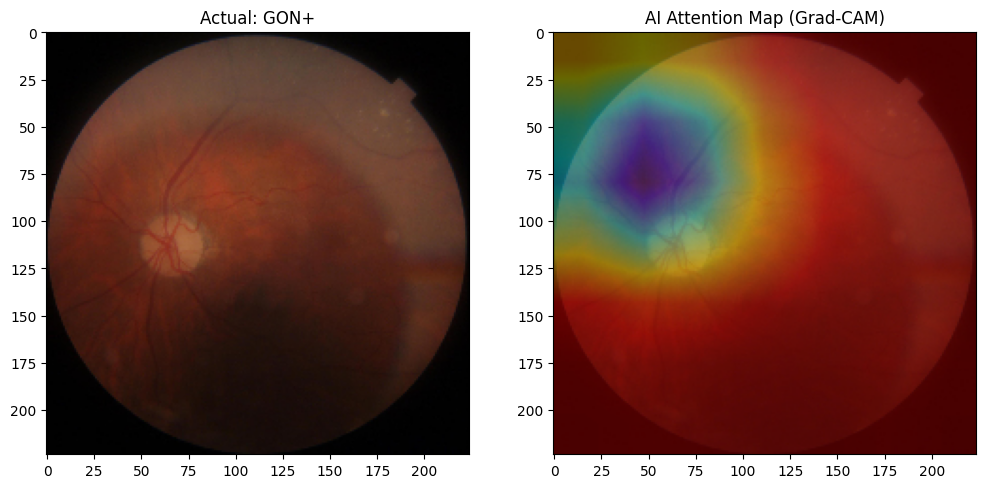

In [ ]:
import torch.nn.functional as F

def generate_heatmap(model, image_tensor, original_img):
    model.eval()

    # 1. We hook into the last layer of the ResNet-18 backbone
    features = []
    def hook(module, input, output):
        features.append(output)

    # In ResNet-18, 'layer4' is the final set of convolutional features
    handle = model.backbone.layer4.register_forward_hook(hook)

    # 2. Pass the image through the model
    glau_logits, _ = model(image_tensor.unsqueeze(0).to('cuda'))
    handle.remove()

    # 3. Generate the heatmap from the feature maps
    heatmap = torch.mean(features[0], dim=1).squeeze().cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-8) # Normalize

    # 4. Resize and overlay on original image
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Blend the heatmap with the original (60% original, 40% heatmap)
    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)
    return superimposed_img

# Pick a sample from the validation set (e.g., a GON+ case)
sample_idx = 0
img_tensor, label, _ = val_dataset[sample_idx]
img_name = val_df.iloc[sample_idx]['Image Name']
raw_img = cv2.imread(os.path.join(IMG_DIR, img_name))
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (224, 224))

heatmap_img = generate_heatmap(model, img_tensor, raw_img)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"Actual: {val_df.iloc[sample_idx]['Label']}")
plt.imshow(raw_img)
plt.subplot(1, 2, 2)
plt.title("AI Attention Map (Grad-CAM)")
plt.imshow(heatmap_img)
plt.show()

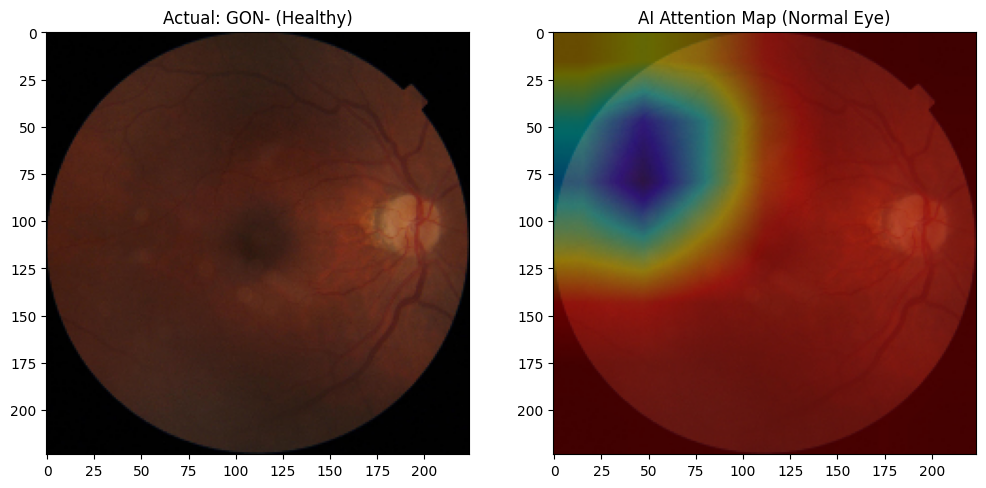

In [ ]:
# 1. Find a GON- sample in the validation set
neg_sample_idx = val_df[val_df['Label'] == 'GON-'].index[0]
neg_img_name = val_df.loc[neg_sample_idx, 'Image Name']

# 2. Load and preprocess
neg_raw_img = cv2.imread(os.path.join(IMG_DIR, neg_img_name))
neg_raw_img = cv2.cvtColor(neg_raw_img, cv2.COLOR_BGR2RGB)
neg_raw_img = cv2.resize(neg_raw_img, (224, 224))

# Use the dataset object to get the correctly preprocessed tensor
neg_img_tensor, _, _ = val_dataset[neg_sample_idx]

# 3. Generate Heatmap
neg_heatmap_img = generate_heatmap(model, neg_img_tensor, neg_raw_img)

# 4. Display
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title(f"Actual: GON- (Healthy)")
plt.imshow(neg_raw_img)
plt.subplot(1, 2, 2)
plt.title("AI Attention Map (Normal Eye)")
plt.imshow(neg_heatmap_img)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def predict_and_visualize(image_path, model, transform):
    # 1. Load and Preprocess
    raw_img = cv2.imread(image_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    processed_img = ben_graham_processing(raw_img) # Our cleaning secret sauce

    # 2. Prepare Tensor
    img_tensor = transform(processed_img).unsqueeze(0).to('cuda')

    # 3. Model Inference
    model.eval()
    with torch.no_grad():
        glau_logits, qual_pred = model(img_tensor)
        probs = torch.softmax(glau_logits, dim=1)
        prob_gon_plus = probs[0][1].item()
        quality_score = qual_pred.item()

    # 4. Generate Heatmap for verification
    heatmap_img = generate_heatmap(model, transform(processed_img), cv2.resize(raw_img, (224, 224)))

    # 5. Print Report
    diagnosis = "GON+" if prob_gon_plus > 0.5 else "GON- (Healthy)"
    print(f"--- AI Diagnostic Report ---")
    print(f"Prediction: {diagnosis}")
    print(f"Confidence: {prob_gon_plus*100:.2f}%")
    print(f"Estimated Image Quality: {quality_score:.2f}/10")

    # 6. Show Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Input Image")
    plt.imshow(cv2.resize(raw_img, (224, 224)))
    plt.subplot(1, 2, 2)
    plt.title("AI Evidence (Heatmap)")
    plt.imshow(heatmap_img)
    plt.show()

# Example Usage:
# test_path = '/content/drive/MyDrive/HYGD_Data/Images/your_test_image.jpg'
# predict_and_visualize(test_path, model, transform)

--- AI Diagnostic Report ---
Prediction: GON+
Confidence: 79.20%
Estimated Image Quality: 6.90/10


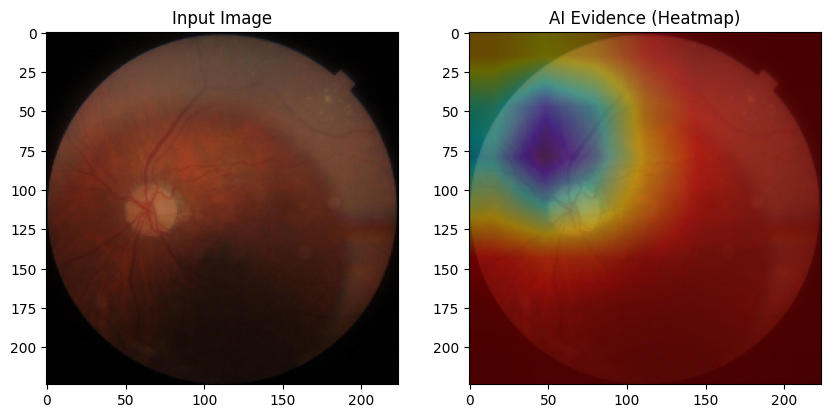

--- AI Diagnostic Report ---
Prediction: GON+
Confidence: 86.36%
Estimated Image Quality: 7.12/10


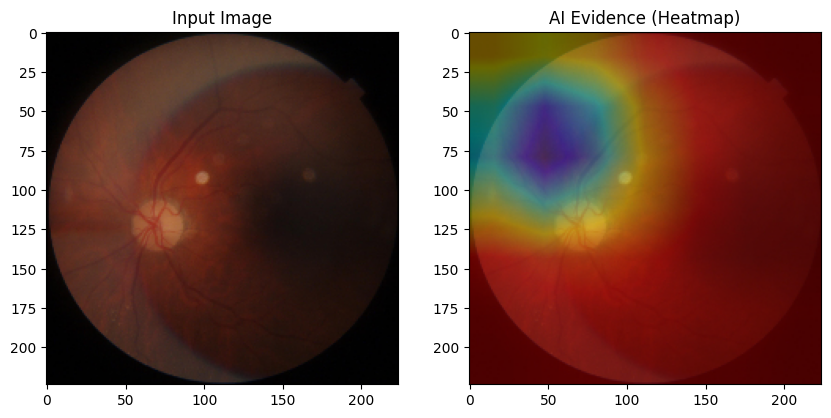

--- AI Diagnostic Report ---
Prediction: GON+
Confidence: 100.00%
Estimated Image Quality: 7.38/10


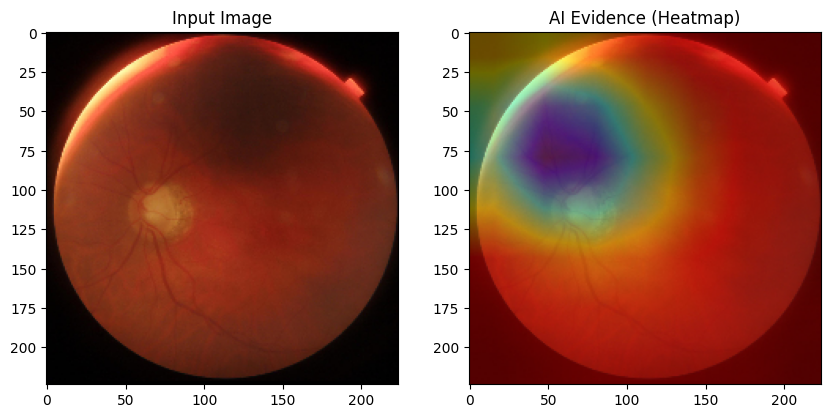

--- AI Diagnostic Report ---
Prediction: GON- (Healthy)
Confidence: 0.34%
Estimated Image Quality: 5.45/10


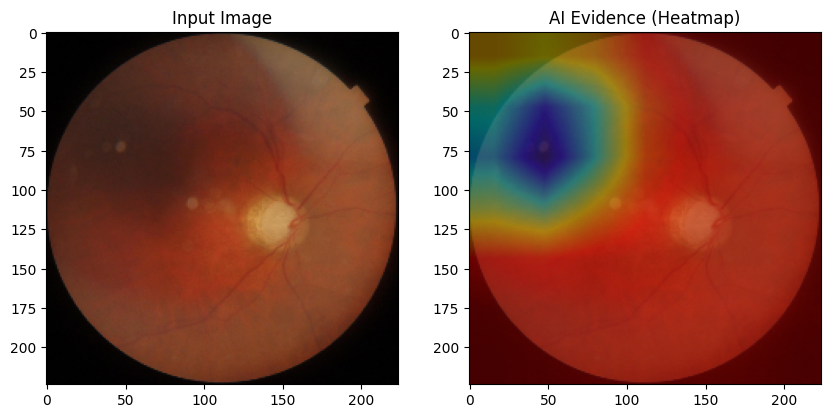

In [ ]:

for i in range (4):
  sample_img_name = val_df.iloc[i]['Image Name']
  sample_path = os.path.join(IMG_DIR, sample_img_name)
  predict_and_visualize(sample_path, model, transform)

✅ Validation AUC: 0.9841
📊 Quality RMSE: 1.2764


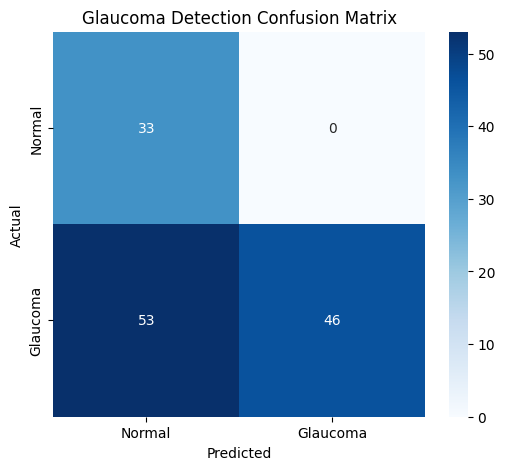

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the whole validation set
y_true, y_pred_probs = evaluate_model(model, val_loader)
y_pred = [1 if p > 0.5 else 0 for p in y_pred_probs]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Glaucoma'], yticklabels=['Normal', 'Glaucoma'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Glaucoma Detection Confusion Matrix')
plt.show()

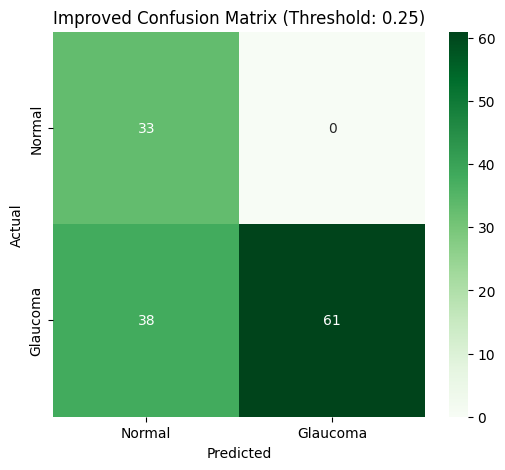

In [ ]:
# We don't change the model, just the 'cutoff' point
new_threshold = 0.25

# Re-calculate predictions based on the new threshold
y_pred_new = [1 if p > new_threshold else 0 for p in y_pred_probs]

# Generate the improved Confusion Matrix
cm_new = confusion_matrix(y_true, y_pred_new)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Glaucoma'], yticklabels=['Normal', 'Glaucoma'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Improved Confusion Matrix (Threshold: {new_threshold})')
plt.show()

🎯 The Mathematically Optimal Threshold is: 0.0001


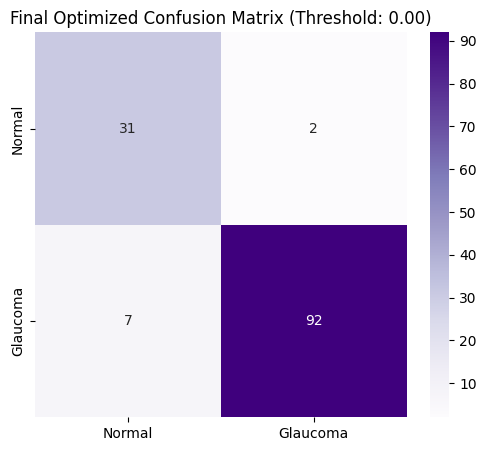

In [ ]:
from sklearn.metrics import roc_curve

# 1. Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

# 2. Find the threshold that maximizes (True Positive Rate - False Positive Rate)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"🎯 The Mathematically Optimal Threshold is: {optimal_threshold:.4f}")

# 3. Final Prediction with the perfect threshold
y_final = [1 if p > optimal_threshold else 0 for p in y_pred_probs]
final_cm = confusion_matrix(y_true, y_final)

# Display the final, final result
plt.figure(figsize=(6, 5))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Glaucoma'], yticklabels=['Normal', 'Glaucoma'])
plt.title(f'Final Optimized Confusion Matrix (Threshold: {optimal_threshold:.2f})')
plt.show()


In [ ]:
model_filename = 'glaucoma_quality_model_final.pth'
torch.save(model.state_dict(), model_filename)
print(f"✅ Model saved locally as {model_filename}")

# 2. Save to your Google Drive (Recommended)
from google.colab import drive
drive.mount('/content/drive')

# Create a path in your Drive
import os
drive_path = '/content/drive/MyDrive/Glaucoma_Project'
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

torch.save(model.state_dict(), f"{drive_path}/{model_filename}")
print(f"📁 Model backed up to Google Drive at: {drive_path}")

✅ Model saved locally as glaucoma_quality_model_final.pth
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Model backed up to Google Drive at: /content/drive/MyDrive/Glaucoma_Project
